In [2]:
import pandas as pd
df = pd.read_csv("../Data/clean/airbnb_cleaned.csv")
df.head()

,title,lat,lng,rating_overall,reviews_count,rating_accuracy,rating_cleanliness,rating_value,rating_location,price_total,price_original,discount_amount,has_rating,bedrooms,bathrooms,description_length,has_wifi,has_pool,has_pyramid_view
0,"ETERNA.Suite W Jaccuzi, Pyramids View & Balcony",29.973873,31.146603,4.95,133.0,4.96,4.92,4.92,4.79,675,750.0,75.0,True,1,1.0,328,True,True,False
1,king khufu suite,29.986300,31.143100,5.00,62.0,5.00,5.00,4.97,4.85,527,527.0,0.0,True,1,1.0,80,False,True,True
2,Akasia Pyramids View,29.978100,31.145400,4.91,176.0,4.91,4.91,4.95,4.78,194,194.0,0.0,True,1,1.0,98,False,False,True
3,Mountain Cave | Pyramids View & Jacuzzi,29.979090,31.146920,4.92,12.0,5.00,4.75,4.58,4.75,593,593.0,0.0,True,1,1.0,249,True,True,True
4,Heaven of Pyramids,29.978787,31.144191,4.71,125.0,4.74,4.61,4.80,4.66,117,117.0,0.0,True,1,1.0,119,False,False,True


In [3]:
df.columns.tolist()

['title',
 'lat',
 'lng',
 'rating_overall',
 'reviews_count',
 'rating_accuracy',
 'rating_cleanliness',
 'rating_value',
 'rating_location',
 'price_total',
 'price_original',
 'discount_amount',
 'has_rating',
 'bedrooms',
 'bathrooms',
 'description_length',
 'has_wifi',
 'has_pool',
 'has_pyramid_view']

In [4]:
print(df.isnull().sum())

title                 0
lat                   0
lng                   0
rating_overall        0
reviews_count         0
rating_accuracy       0
rating_cleanliness    0
rating_value          0
rating_location       0
price_total           0
price_original        0
discount_amount       0
has_rating            0
bedrooms              0
bathrooms             0
description_length    0
has_wifi              0
has_pool              0
has_pyramid_view      0
dtype: int64


In [5]:
print(df['has_rating'].value_counts())

has_rating
True     466
False    365
Name: count, dtype: int64


In [6]:
import pandas as pd
df = pd.read_csv("../Data/clean/airbnb_cleaned.csv")

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# ──  Drop Useless Columns ──────────────────────────────────────────
df.drop(columns=[
    'title', 'price_total', 'discount_amount', 
    'has_rating'
], inplace=True)



# ──  Helper: Evaluate Any Model ───────────────────────────────────
def evaluate(name, Y_test, Y_pred):
    mae  = mean_absolute_error(Y_test, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    r2   = r2_score(Y_test, Y_pred)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE  : {mae:.2f}  (off by ${mae:.2f} on average)")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")


# ── 9. Save Models ───────────────────────────────────────────────────
# import joblib
# joblib.dump(lr,  'Models/linear_regression.pkl')
# joblib.dump(xgb, 'Models/xgboost_model.pkl')
# print("\n✅ Models saved successfully!")

count       831.000000
mean       4651.080626
std       14260.140406
min          65.000000
25%         677.000000
50%        1780.000000
75%        3714.000000
max      284165.000000
Name: price_original, dtype: float64


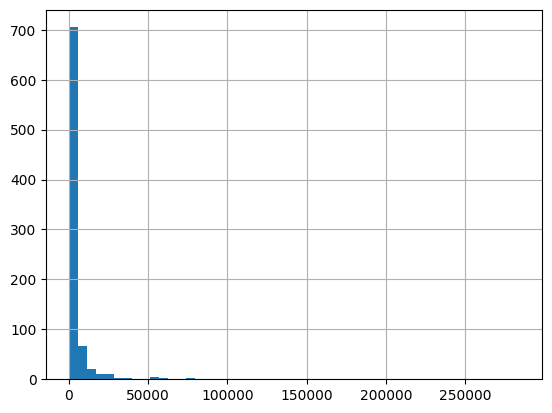

count       831.000000
mean       4651.080626
std       14260.140406
min          65.000000
25%         677.000000
50%        1780.000000
75%        3714.000000
max      284165.000000
Name: price_original, dtype: float64
Keeping prices between: -3878 and 8270
Rows before: 831
Rows after: 752


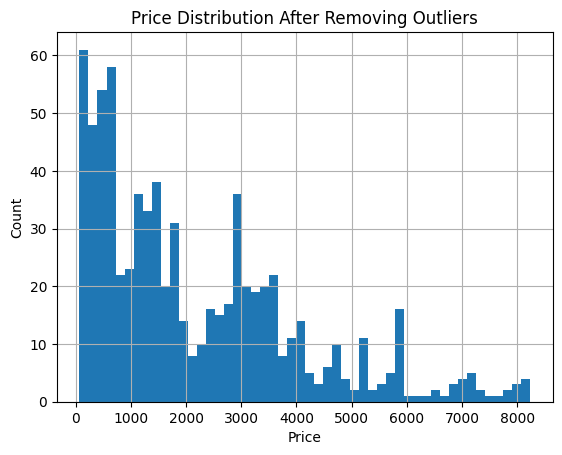

In [8]:
import matplotlib.pyplot as plt

print(df['price_original'].describe())
df['price_original'].hist(bins=50)
plt.show()
# Check the actual numbers first
print(df['price_original'].describe())

# Remove outliers using IQR method
Q1 = df['price_original'].quantile(0.25)
Q3 = df['price_original'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Keeping prices between: {lower:.0f} and {upper:.0f}")
print(f"Rows before: {len(df)}")

df_clean = df[(df['price_original'] >= lower) & 
              (df['price_original'] <= upper)]

print(f"Rows after: {len(df_clean)}")

# Check new distribution
df_clean['price_original'].hist(bins=50)
plt.title('Price Distribution After Removing Outliers')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

In [9]:
# ──  Define X and Y ────────────────────────────────────────────────
Y = df_clean['price_original']
X = df_clean.drop(columns=['price_original'])

# ──  Train/Test Split ──────────────────────────────────────────────
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
# ──  Linear Regression ────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, Y_train)
Y_pred_lr = lr.predict(X_test)
evaluate("Linear Regression", Y_test, Y_pred_lr)


  Linear Regression
  MAE  : 1305.72  (off by $1305.72 on average)
  RMSE : 1873.16
  R²   : 0.2423  (24.2% variance explained)


In [10]:
# ──  XGBoost ──────────────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
xgb.fit(X_train, Y_train)
Y_pred_xgb = xgb.predict(X_test)
evaluate("XGBoost", Y_test, Y_pred_xgb)


  XGBoost
  MAE  : 1025.87  (off by $1025.87 on average)
  RMSE : 1622.22
  R²   : 0.4317  (43.2% variance explained)


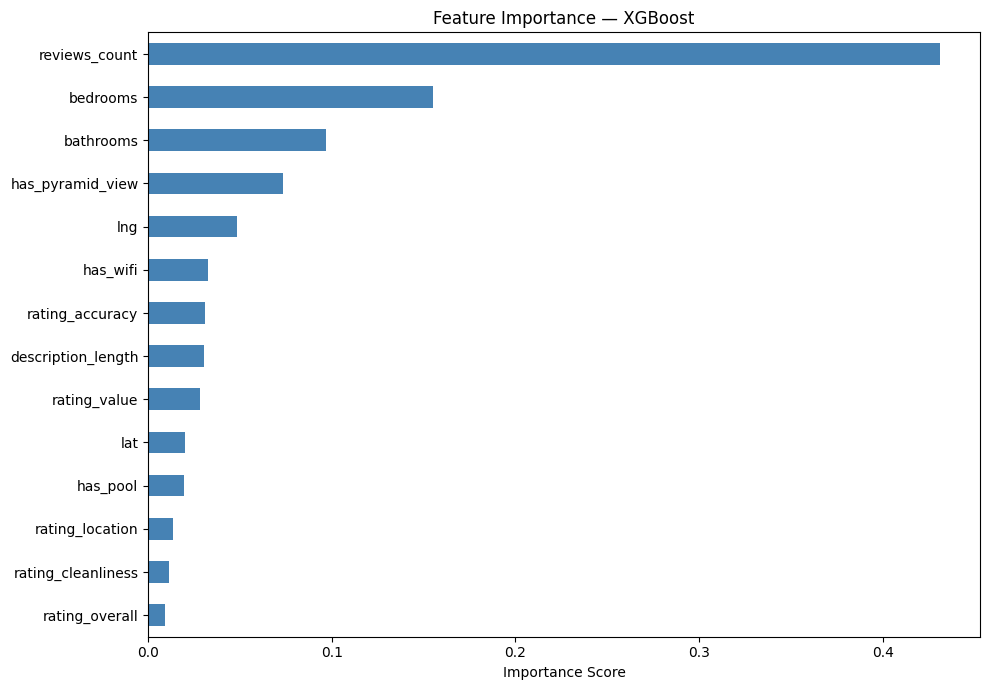


  XGBoost V2 (cleaned features)
  MAE  : 1016.66  (off by $1016.66 on average)
  RMSE : 1645.04
  R²   : 0.4156  (41.6% variance explained)


In [11]:
# ──  Feature Importance (XGBoost) ─────────────────────────────────
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(10, 7), color='steelblue')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
# Drop features with near-zero importance
cols_to_drop = ['rating_cleanliness', 'rating_location', 
                'rating_accuracy', 'has_pyramid_view', 'rating_value']

X_train_v2 = X_train.drop(columns=cols_to_drop)
X_test_v2  = X_test.drop(columns=cols_to_drop)

xgb_v2 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_v2.fit(X_train_v2, Y_train)
Y_pred_v2 = xgb_v2.predict(X_test_v2)
evaluate("XGBoost V2 (cleaned features)", Y_test, Y_pred_v2)

In [12]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)
evaluate("Random Forest", Y_test, rf.predict(X_test))

# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, Y_train)
evaluate("Gradient Boosting", Y_test, gb.predict(X_test))
# import joblib
# import os

# os.makedirs('Models', exist_ok=True)

# joblib.dump(xgb, 'Models/xgboost_model.pkl')
# joblib.dump(lr,  'Models/linear_regression.pkl')

# # Also save the feature columns for Streamlit later
# import json
# with open('Models/feature_columns.json', 'w') as f:
#     json.dump(X_train.columns.tolist(), f)

# print("✅ Models saved!")


  Random Forest
  MAE  : 965.42  (off by $965.42 on average)
  RMSE : 1586.86
  R²   : 0.4562  (45.6% variance explained)

  Gradient Boosting
  MAE  : 1051.90  (off by $1051.90 on average)
  RMSE : 1674.85
  R²   : 0.3943  (39.4% variance explained)
